# **Brain Stroke**

# **import Statements**

In [4]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report


ModuleNotFoundError: No module named 'matplotlib'

In [6]:
data = pd.read_csv(r, 'hemorrhage_diagnosis.csv')

NameError: name 'pd' is not defined

In [218]:
data.head()

,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
0,49,1,0,0,0,0,0,1,0
1,49,2,0,0,0,0,0,1,0
2,49,3,0,0,0,0,0,1,0
3,49,4,0,0,0,0,0,1,0
4,49,5,0,0,0,0,0,1,0


In [2]:
data.tail()

NameError: name 'data' is not defined

# **Information about Data set**

In [3]:
# check the shape of the data set
data.shape

NameError: name 'data' is not defined

In [221]:
# show the what are the column thare in this data set
data.columns

Index(['PatientNumber', 'SliceNumber', 'Intraventricular', 'Intraparenchymal',
       'Subarachnoid', 'Epidural', 'Subdural', 'No_Hemorrhage',
       'Fracture_Yes_No'],
      dtype='object')

In [222]:
# check the information about column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2501 entries, 0 to 2500
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientNumber     2501 non-null   int64
 1   SliceNumber       2501 non-null   int64
 2   Intraventricular  2501 non-null   int64
 3   Intraparenchymal  2501 non-null   int64
 4   Subarachnoid      2501 non-null   int64
 5   Epidural          2501 non-null   int64
 6   Subdural          2501 non-null   int64
 7   No_Hemorrhage     2501 non-null   int64
 8   Fracture_Yes_No   2501 non-null   int64
dtypes: int64(9)
memory usage: 176.0 KB


In [223]:
# check the null value
data.isnull().sum()

PatientNumber       0
SliceNumber         0
Intraventricular    0
Intraparenchymal    0
Subarachnoid        0
Epidural            0
Subdural            0
No_Hemorrhage       0
Fracture_Yes_No     0
dtype: int64

In [224]:
# check the duplicate value
data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2496    False
2497    False
2498    False
2499    False
2500    False
Length: 2501, dtype: bool

In [225]:
# check the values of target column
data['Fracture_Yes_No'].value_counts()

0    2306
1     195
Name: Fracture_Yes_No, dtype: int64

## **EDA**

c:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Fracture_Yes_No', ylabel='count'>

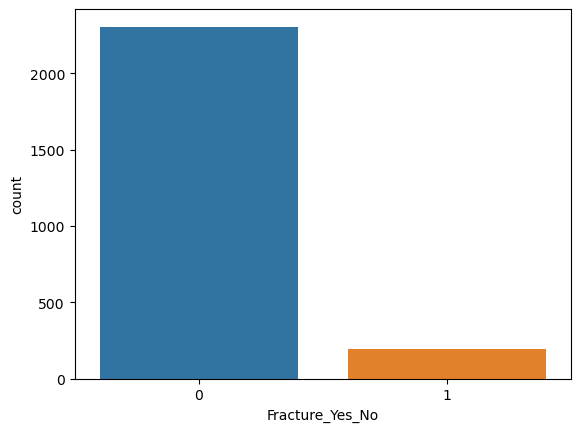

In [226]:
sns.countplot(data['Fracture_Yes_No'])

<AxesSubplot:xlabel='Fracture_Yes_No', ylabel='Count'>

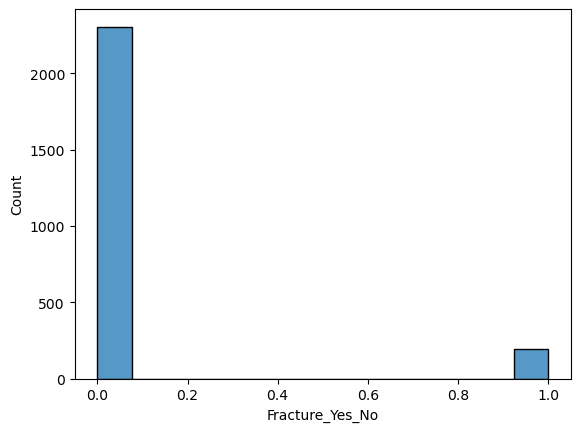

In [227]:
sns.histplot(data["Fracture_Yes_No"])

c:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='No_Hemorrhage', ylabel='count'>

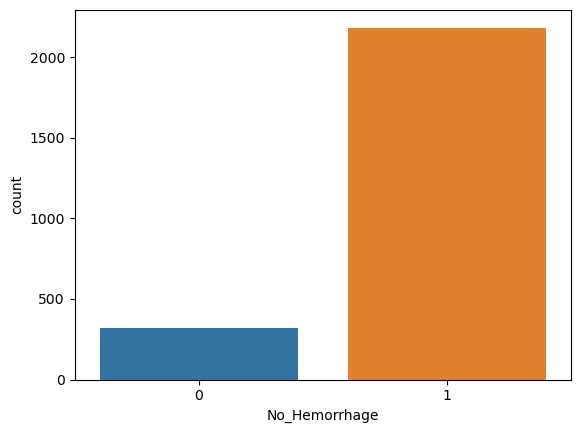

In [228]:
sns.countplot(data['No_Hemorrhage'])

<AxesSubplot:xlabel='PatientNumber', ylabel='Count'>

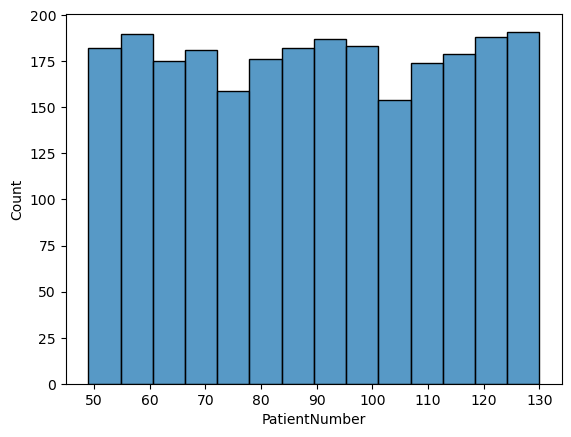

In [229]:
sns.histplot(data["PatientNumber"])

<AxesSubplot:xlabel='SliceNumber', ylabel='Count'>

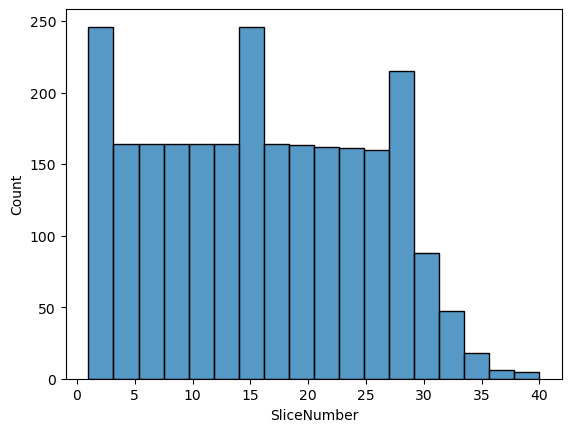

In [230]:
sns.histplot(data["SliceNumber"])

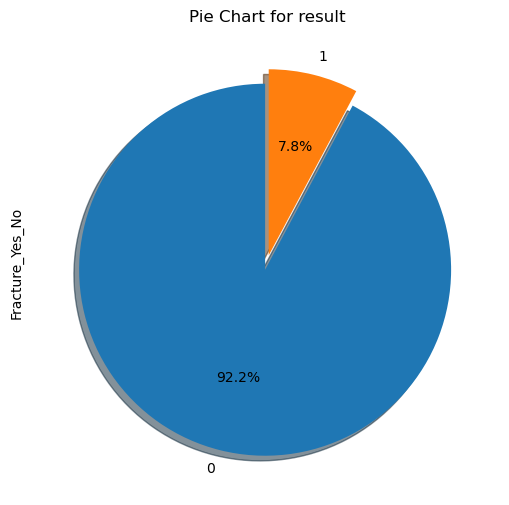

In [231]:
data['Fracture_Yes_No'].value_counts().plot.pie(explode=[0.04,0.04], autopct='%1.1f%%',  startangle=90,shadow=True, figsize=(6,8))
plt.title('Pie Chart for result')
plt.show()

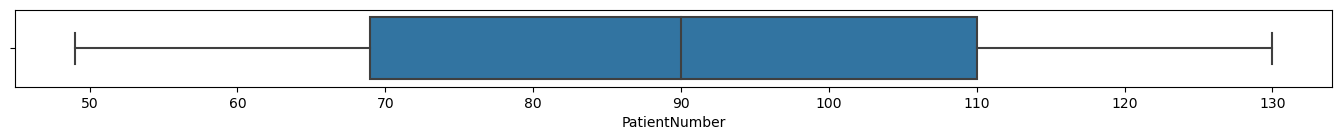

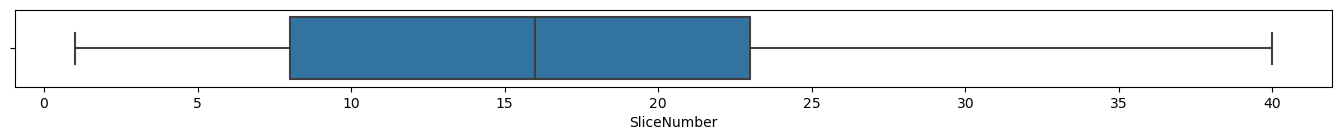

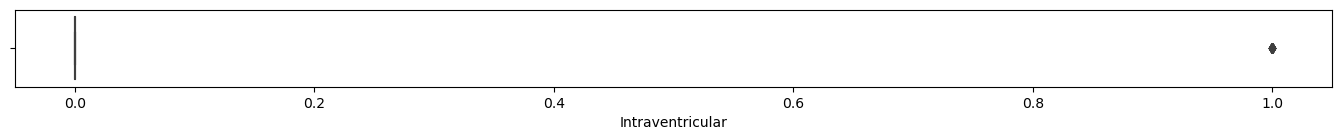

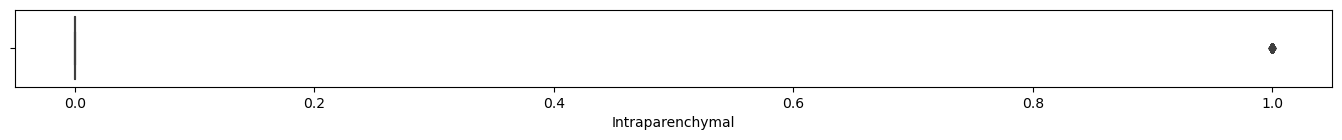

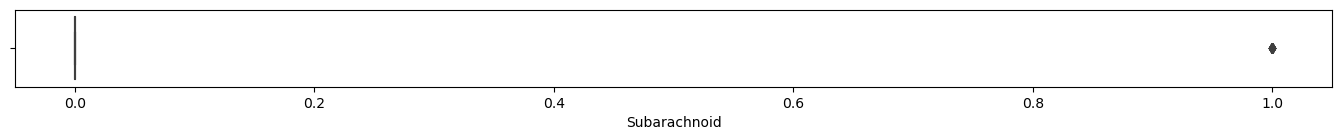

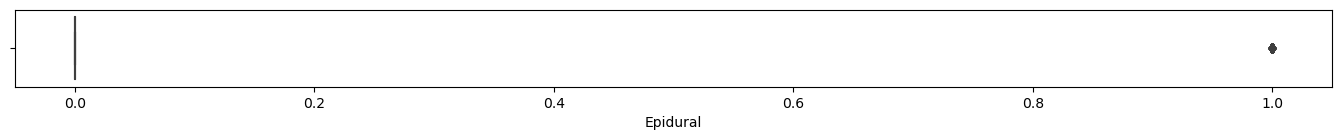

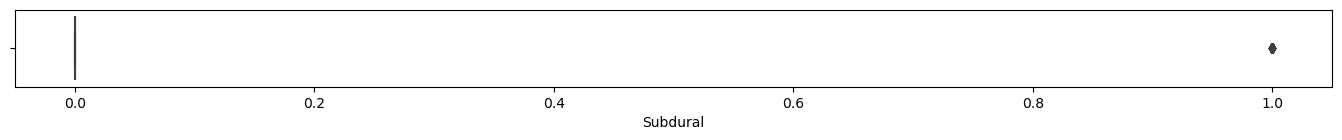

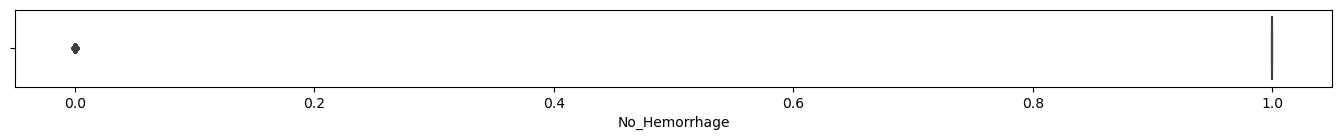

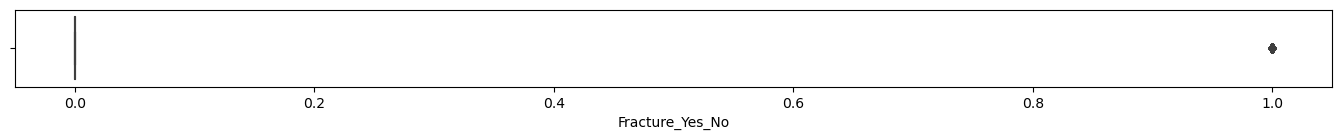

In [232]:
df1=data.select_dtypes(exclude=['object','bool'])
for column in df1:
        plt.figure(figsize=(17,1))
        sns.boxplot(data=df1, x=column)
plt.show()

c:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Fracture_Yes_No', ylabel='Density'>

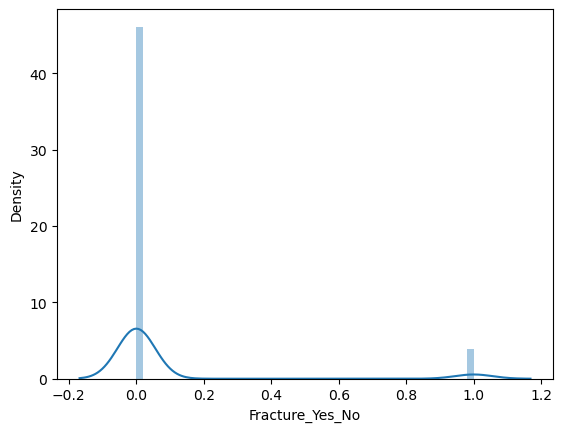

In [233]:
sns.distplot(data['Fracture_Yes_No'])

## **data Correlation**

In [234]:
data.corr()

,PatientNumber,SliceNumber,Intraventricular,Intraparenchymal,Subarachnoid,Epidural,Subdural,No_Hemorrhage,Fracture_Yes_No
PatientNumber,1.000000,0.005611,-0.011945,-0.115493,-0.023821,-0.167029,-0.132763,0.247143,-0.186007
SliceNumber,0.005611,1.000000,0.011382,0.075322,0.025361,0.088719,0.078983,-0.144081,0.121121
Intraventricular,-0.011945,0.011382,1.000000,0.202214,0.137179,-0.026833,-0.014897,-0.257903,0.063156
Intraparenchymal,-0.115493,0.075322,0.202214,1.000000,0.125736,-0.009825,0.037976,-0.454308,0.277358
Subarachnoid,-0.023821,0.025361,0.137179,0.125736,1.000000,0.014072,-0.012886,-0.223080,0.081091
Epidural,-0.167029,0.088719,-0.026833,-0.009825,0.014072,1.000000,-0.041256,-0.714241,0.249837
Subdural,-0.132763,0.078983,-0.014897,0.037976,-0.012886,-0.041256,1.000000,-0.396523,0.228134
No_Hemorrhage,0.247143,-0.144081,-0.257903,-0.454308,-0.223080,-0.714241,-0.396523,1.000000,-0.430654
Fracture_Yes_No,-0.186007,0.121121,0.063156,0.277358,0.081091,0.249837,0.228134,-0.430654,1.000000


<AxesSubplot:>

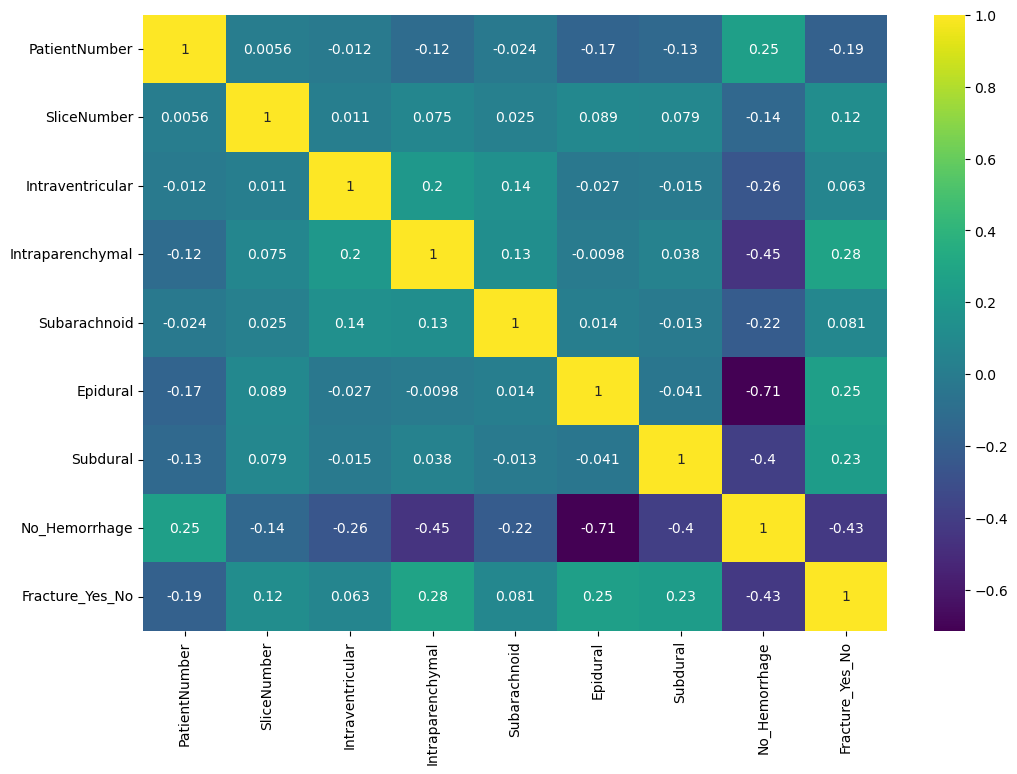

In [235]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='viridis')

# **Splite the Data**

In [236]:
x = data.drop("Fracture_Yes_No", axis=1)
y = data["Fracture_Yes_No"]

In [237]:
x.shape

(2501, 8)

In [238]:
y.shape

(2501,)

### **Applying the Smote Methos**

In [239]:
Oversample = SMOTE()
x_sm, y_sm = Oversample.fit_resample(x,y)

In [240]:
x_sm.shape

(4612, 8)

In [241]:
y_sm.shape

(4612,)

## **split the data**

In [242]:
x_train,x_test,y_train,y_test = train_test_split(x_sm,y_sm,test_size=0.3,random_state=72)

In [243]:
x_train.shape

(3228, 8)

In [244]:
x_test.shape

(1384, 8)

In [245]:
y_train.shape

(3228,)

In [246]:
y_test.shape

(1384,)

# **Apply algorithms**

## **KNN**

In [247]:
kn = KNeighborsClassifier()
kn.fit(x_train,y_train)
k_pred = kn.predict(x_test)
k_ac = accuracy_score(k_pred, y_test)
k_acc = classification_report(k_pred, y_test)
print(k_acc)
print("accuracy_score of knn is"+": "+str(k_ac))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       610
           1       1.00      0.90      0.94       774

    accuracy                           0.94      1384
   macro avg       0.94      0.95      0.94      1384
weighted avg       0.95      0.94      0.94      1384

accuracy_score of knn is: 0.9407514450867052


## **LogisticRegression**

In [248]:
ln = LogisticRegression()
ln.fit(x_train,y_train)
l_pred = ln.predict(x_test)
l_ac = accuracy_score(l_pred, y_test)
l_acc = classification_report(l_pred, y_test)
print(l_acc)
print("accuracy_score of LogisticRegression is"+": "+str(l_ac))


              precision    recall  f1-score   support

           0       0.90      0.77      0.83       810
           1       0.73      0.88      0.80       574

    accuracy                           0.82      1384
   macro avg       0.82      0.82      0.81      1384
weighted avg       0.83      0.82      0.82      1384

accuracy_score of LogisticRegression is: 0.815028901734104


C:\Users\ymts0630\AppData\Roaming\Python\Python39\site-packages\sklearn\linear_model\_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## **Naive Bias**

In [249]:
nb = GaussianNB()
nb.fit(x_train,y_train)
nb_pred = nb.predict(x_test)
nb_ac = accuracy_score(y_test,nb_pred)
nb_acc =classification_report(y_test,nb_pred)
print(nb_acc)
print("accuracy_score of Naive Bias is"+": "+str(nb_ac))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83       688
           1       0.88      0.73      0.80       696

    accuracy                           0.82      1384
   macro avg       0.83      0.82      0.82      1384
weighted avg       0.83      0.82      0.82      1384

accuracy_score of Naive Bias is: 0.8164739884393064


## **Decision Tree**

In [250]:
de = DecisionTreeClassifier()
de.fit(x_train,y_train)
de_pred = de.predict(x_test)
de_ac = accuracy_score(y_test,de_pred)
de_acc =classification_report(y_test,de_pred)
print(de_acc)
print("accuracy_score of DecisionTreeClassifier is"+": "+str(de_ac))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       688
           1       0.98      0.98      0.98       696

    accuracy                           0.98      1384
   macro avg       0.98      0.98      0.98      1384
weighted avg       0.98      0.98      0.98      1384

accuracy_score of DecisionTreeClassifier is: 0.9812138728323699


## **Random Forest**

In [251]:
rn = RandomForestClassifier()
rn.fit(x_train,y_train)
rn_pred = rn.predict(x_test)
rn_ac = accuracy_score(y_test,rn_pred)
rn_acc =classification_report(y_test,rn_pred)
print(rn_acc)
print("accuracy_score of RandomForestClassifier is"+": "+str(rn_ac))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       688
           1       0.98      0.98      0.98       696

    accuracy                           0.98      1384
   macro avg       0.98      0.98      0.98      1384
weighted avg       0.98      0.98      0.98      1384

accuracy_score of RandomForestClassifier is: 0.9790462427745664


## **multilayer perceptron**

In [252]:
ml = MLPClassifier()
ml.fit(x_train,y_train)
ml_pred = ml.predict(x_test)
ml_ac = accuracy_score(y_test,ml_pred)
ml_acc =classification_report(y_test,ml_pred)
print(ml_acc)
print("accuracy_score of MLPClassifier is"+": "+str(ml_ac))

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       688
           1       0.89      0.71      0.79       696

    accuracy                           0.81      1384
   macro avg       0.83      0.81      0.81      1384
weighted avg       0.83      0.81      0.81      1384

accuracy_score of MLPClassifier is: 0.8128612716763006


## **Support Vectore Machine**

In [253]:
sv = SVC()
sv.fit(x_train,y_train)
sv_pred = sv.predict(x_test)
sv_ac = accuracy_score(y_test,sv_pred)
sv_acc =classification_report(y_test,sv_pred)
print(sv_acc)
print("accuracy_score of SVC is"+": "+str(sv_ac))

              precision    recall  f1-score   support

           0       0.88      0.58      0.70       688
           1       0.69      0.92      0.79       696

    accuracy                           0.76      1384
   macro avg       0.79      0.75      0.75      1384
weighted avg       0.79      0.76      0.75      1384

accuracy_score of SVC is: 0.755057803468208


## **CetBoost**

In [254]:
cb = CatBoostClassifier()
cb.fit(x_train,y_train)
cb_pred = cb.predict(x_test)
cb_ac = accuracy_score(y_test,cb_pred)
cb_acc = classification_report(y_test,cb_pred)
print(cb_acc)
print("accuracy_score of CatBoostClassifier is"+": "+str(cb_ac))


Learning rate set to 0.016992
0:	learn: 0.6729668	total: 2.37ms	remaining: 2.37s
1:	learn: 0.6574682	total: 4.13ms	remaining: 2.06s
2:	learn: 0.6400087	total: 5.92ms	remaining: 1.97s
3:	learn: 0.6202721	total: 7.99ms	remaining: 1.99s
4:	learn: 0.6059013	total: 10.2ms	remaining: 2.02s
5:	learn: 0.5897640	total: 12.1ms	remaining: 2s
6:	learn: 0.5761190	total: 14.2ms	remaining: 2.01s
7:	learn: 0.5636607	total: 15.9ms	remaining: 1.97s
8:	learn: 0.5461399	total: 17.9ms	remaining: 1.97s
9:	learn: 0.5337488	total: 19.8ms	remaining: 1.96s
10:	learn: 0.5243024	total: 21.9ms	remaining: 1.97s
11:	learn: 0.5112658	total: 23.9ms	remaining: 1.97s
12:	learn: 0.4979360	total: 25.8ms	remaining: 1.96s
13:	learn: 0.4853539	total: 27.9ms	remaining: 1.97s
14:	learn: 0.4813588	total: 29.3ms	remaining: 1.93s
15:	learn: 0.4726166	total: 31.4ms	remaining: 1.93s
16:	learn: 0.4637148	total: 33.7ms	remaining: 1.95s
17:	learn: 0.4554736	total: 35.9ms	remaining: 1.96s
18:	learn: 0.4476276	total: 38.1ms	remaining: 1

# **DataFrame of accuracy**

In [255]:
graph = pd.DataFrame({'Modules':['KNN','Logistic Regration','Naive Bias','Decision Tree','RandomForest','MLP','SVC','CatBoost'],
                    'Accurecy':[k_ac*100,l_ac*100,nb_ac*100,de_ac*100,rn_ac*100,ml_ac*100,sv_ac*100,cb_ac*100]})

In [256]:
graph

,Modules,Accurecy
0,KNN,94.075145
1,Logistic Regration,81.502890
2,Naive Bias,81.647399
3,Decision Tree,98.121387
4,RandomForest,97.904624
5,MLP,81.286127
6,SVC,75.505780
7,CatBoost,98.699422


## **Graph of accuracy**

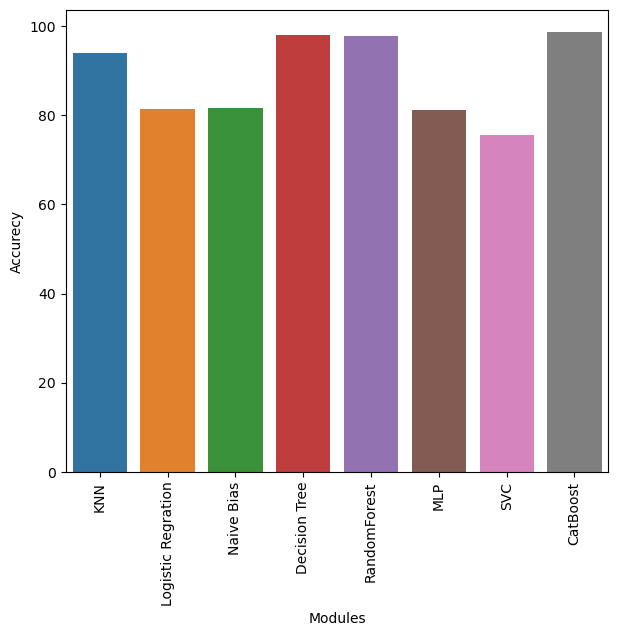

In [257]:
plt.figure(figsize=(7,6))
sns.barplot(y=graph.Accurecy,x=graph.Modules)
plt.xticks(rotation='vertical')
plt.show()

# **Prediction**

**Prediction with CatBoost**

In [258]:
input = [[130,27,0,0,0,0,0,1]]

In [259]:
cb_out = cb.predict(input)
cb_out

array([0], dtype=int64)

In [263]:
if cb_out == 0:
    print("no Chance to get a Brain Stroke")
else:
    print("chance to get a Brain stroke")

no Chance to get a Brain Stroke


In [264]:
input1 = [[49,14,0,0,0,1,0,0]]

In [265]:
cb_out = cb.predict(input1)
cb_out

array([1], dtype=int64)

In [266]:
if cb_out == 0:
    print("no Chance to get a Brain Stroke")
else:
    print("chance to get a Brain stroke")

chance to get a Brain stroke
